## Preview DSM

In [ ]:
DSM_SCALE = 1  # change to 0.05 for very large images
RAW_DSM_PATH = "../dataset/stuff/dsm.tif"

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio
from rasterio.enums import Resampling

raw_dsm = Path(RAW_DSM_PATH)

if not raw_dsm.exists():
    raise FileNotFoundError(f"DSM not found: {raw_dsm.resolve()}")

with rasterio.open(raw_dsm) as src:
    nodata = src.nodata

    arr = src.read(
        1,
        out_shape=(
            int(src.height * DSM_SCALE),
            int(src.width * DSM_SCALE)
        ),
        resampling=Resampling.bilinear
    ).astype(np.float32)

print(f"Loaded preview: {arr.shape}")
print(f"NoData value: {nodata}")

Loaded preview: (512, 512)
NoData value: None


/home/user/CanSat-MHE/data/venv/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [37]:
# Build mask of valid data
mask = np.isfinite(arr)

if nodata is not None:
    mask &= (arr != nodata)

# Optional: remove extreme garbage (common in DSMs)
mask &= (arr > -1000) & (arr < 10000)

# Apply mask → set invalid to NaN
arr_clean = np.where(mask, arr, np.nan)

valid = arr_clean[np.isfinite(arr_clean)]

if valid.size == 0:
    raise ValueError("No valid DSM pixels after filtering")

print(f"Valid pixels: {valid.size:,}")
print(f"Min: {valid.min():.2f} m")
print(f"Max: {valid.max():.2f} m")

Valid pixels: 262,144
Min: 0.00 m
Max: 871.61 m


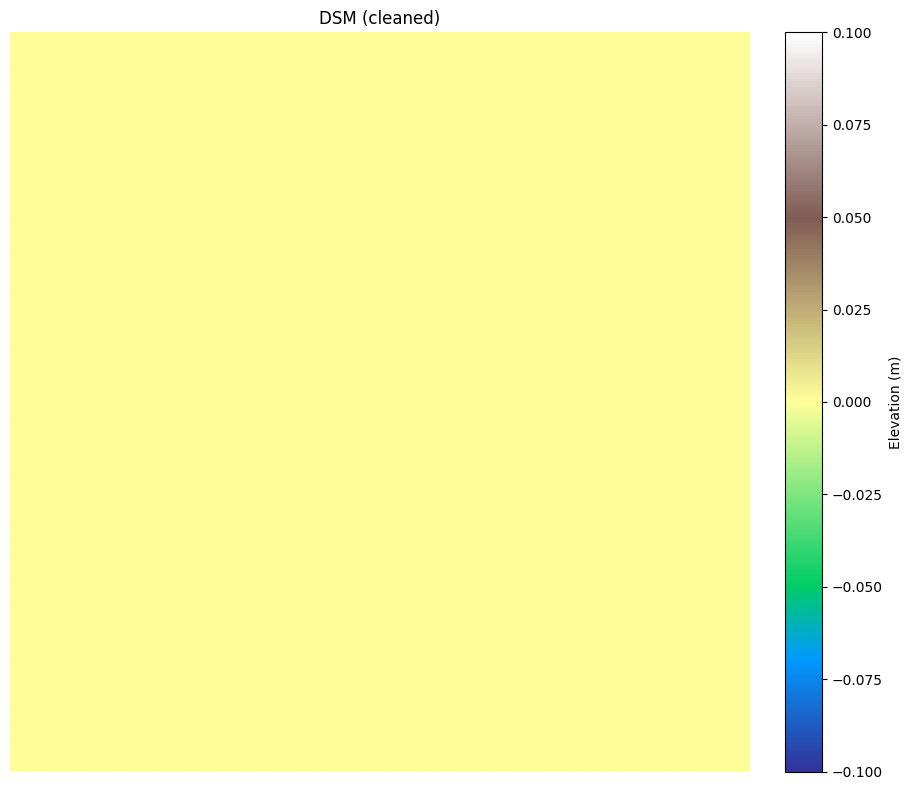

In [38]:
# Percentile-based clipping (ignores NaNs automatically)
vmin = np.nanpercentile(arr_clean, 1)
vmax = np.nanpercentile(arr_clean, 99)

arr_display = np.clip(arr_clean, vmin, vmax)

plt.figure(figsize=(10, 8))

im = plt.imshow(arr_display, cmap="terrain", vmin=vmin, vmax=vmax)

plt.title("DSM (cleaned)")
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Elevation (m)")

plt.tight_layout()
plt.show()

## Preview RGB

In [39]:
USE_NIR = False   # set True if band 1 is NIR and the image is NIR, Red, Green
RGB_SCALE = 1  # adjust if needed
RAW_IMAGE_PATH = "../dataset/stuff/rgb.tif"

In [40]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling

raw_image = Path(RAW_IMAGE_PATH)

if not raw_image.exists():
    raise FileNotFoundError(f"Image not found: {raw_image.resolve()}")

with rasterio.open(raw_image) as src:
    band_count = src.count
    nodata = src.nodata

    new_height = max(1, int(src.height * RGB_SCALE))
    new_width = max(1, int(src.width * RGB_SCALE))

    arr = src.read(
        out_shape=(band_count, new_height, new_width),
        resampling=Resampling.bilinear
    ).astype(np.float32)

print(f"Preview shape: {arr.shape}")   # (bands, height, width)
print(f"Band count: {band_count}")
print(f"NoData: {nodata}")

Preview shape: (3, 512, 512)
Band count: 3
NoData: None


In [41]:
# ---- NORMALIZE ----
max_val = np.nanmax(arr)
if max_val > 1.5:
    scale_div = 255.0 if max_val <= 255 else 65535.0
    arr_norm = arr / scale_div
else:
    arr_norm = arr.copy()

# ---- MODE SELECTION ----
if USE_NIR:
    if arr_norm.shape[0] < 3:
        raise ValueError("NIR mode requires at least 3 bands: NIR, Red, Green")

    nir = arr_norm[0]
    red = arr_norm[1]
    green = arr_norm[2]

    mask = np.isfinite(nir) & np.isfinite(red) & np.isfinite(green)
    if nodata is not None:
        mask &= (arr[0] != nodata) & (arr[1] != nodata) & (arr[2] != nodata)

    veg_index = (nir - red) / (nir + red + 1e-6)
    blue = np.clip(green * (1 - veg_index * 0.3), 0, 1)

    img_array = np.stack([red, green, blue], axis=2)
    title = "Preview (NIR mode)"

else:
    if arr_norm.shape[0] < 3:
        raise ValueError("RGB mode requires at least 3 bands: Red, Green, Blue")

    red = arr_norm[0]
    green = arr_norm[1]
    blue = arr_norm[2]

    mask = np.isfinite(red) & np.isfinite(green) & np.isfinite(blue)
    if nodata is not None:
        mask &= (arr[0] != nodata) & (arr[1] != nodata) & (arr[2] != nodata)

    img_array = np.stack([red, green, blue], axis=2)
    title = "Preview (RGB mode)"

# optional sanity bounds
mask &= np.all(img_array >= 0, axis=2)
mask &= np.all(img_array <= 1.5, axis=2)

valid_pixels = int(mask.sum())
if valid_pixels == 0:
    raise ValueError("No valid pixels after filtering")

img_array[~mask] = np.nan

print(f"Using NIR mode: {USE_NIR}")
print(f"Valid pixels: {valid_pixels:,}")

Using NIR mode: False
Valid pixels: 262,144


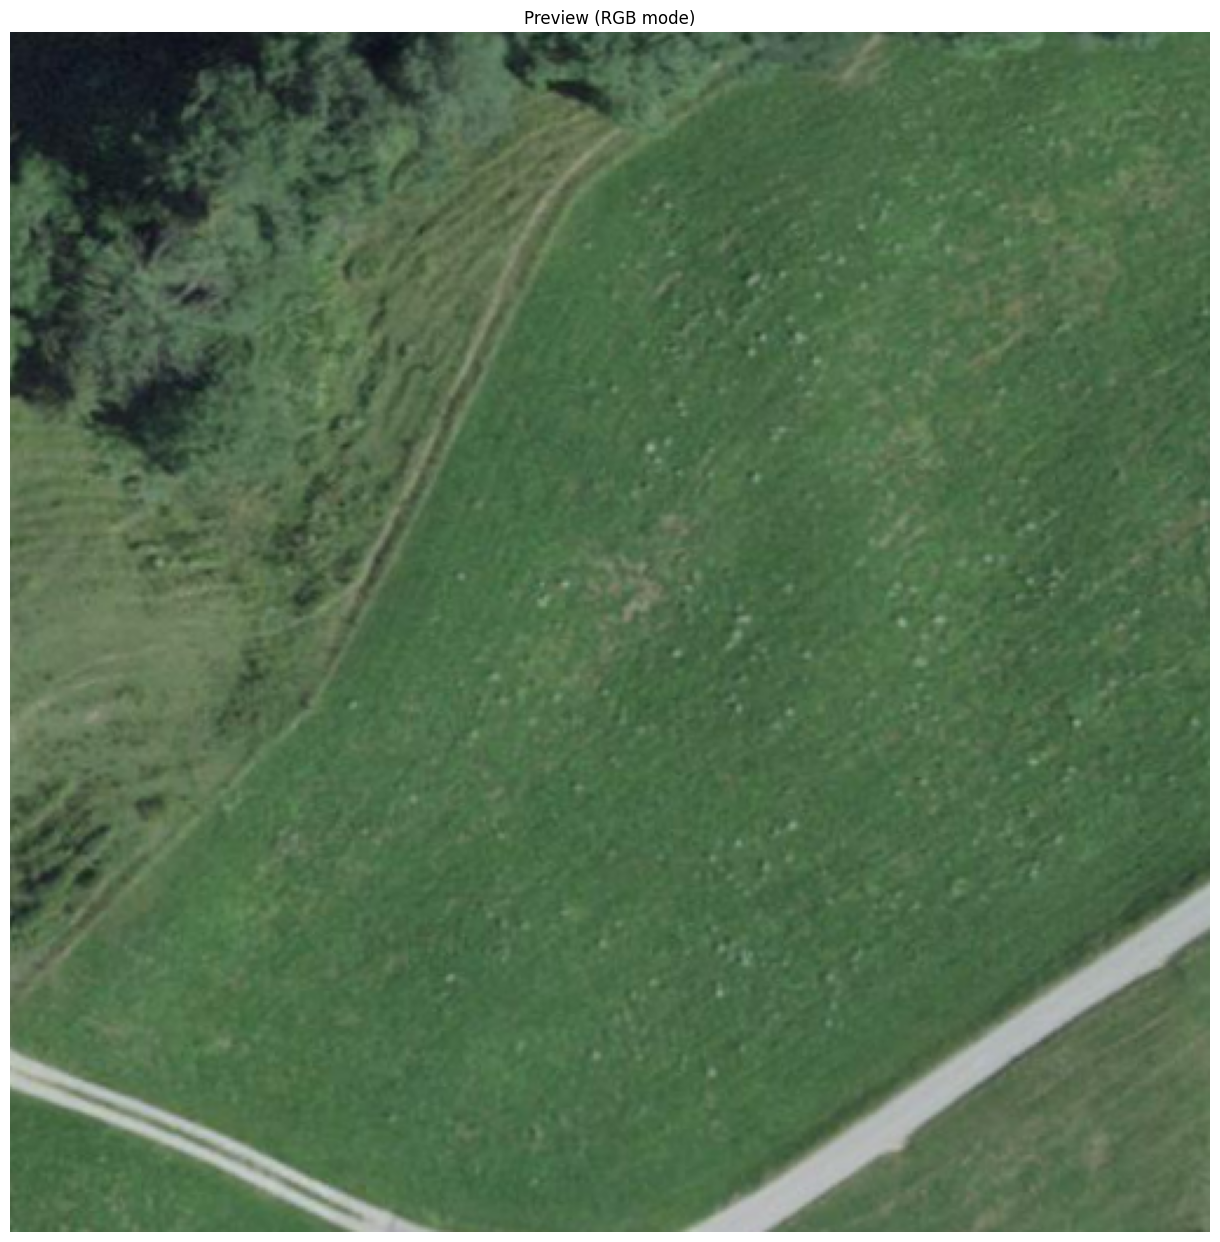

In [42]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(np.clip(img_array, 0, 1))
ax.set_title(title)
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()